In [23]:
# Cell 1: fetch data and create df
import os
from dotenv import load_dotenv
import pandas as pd
from supabase import create_client, Client

load_dotenv(dotenv_path='../.env')

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_ANON_KEY = os.getenv("SUPABASE_ANON_KEY")

supabase: Client = create_client(SUPABASE_URL, SUPABASE_ANON_KEY)
response = supabase.table("nba_historical_game_stats").select("*").execute()

# Depending on your supabase library’s response structure:
data = response.data  # or response.get("data")

df = pd.DataFrame(data)
print("DataFrame created. Shape:", df.shape)


DataFrame created. Shape: (1000, 22)


In [24]:
# Cell 2: operate on df
print(df.dtypes)

# Maybe filter for Knicks
knicks_df = df[df['team_name'].str.contains("Knicks", case=False, na=False)]
print(knicks_df.head())


id                   int64
game_id              int64
player_id            int64
player_name         object
team_id              int64
team_name           object
minutes            float64
points               int64
rebounds             int64
assists              int64
steals               int64
blocks               int64
turnovers            int64
fouls                int64
fg_made              int64
fg_attempted         int64
three_made           int64
three_attempted      int64
ft_made              int64
ft_attempted         int64
game_date           object
updated_at          object
dtype: object
   id  game_id  player_id         player_name  team_id        team_name  \
0   1    23316        606        Tim Hardaway      151  New York Knicks   
1   2    23316      43238             J. Jack      151  New York Knicks   
2   3    23316      36339   E. Kanter Freedom      151  New York Knicks   
3   4    23316      45122              C. Lee      151  New York Knicks   
4   5    23316   

In [25]:
print(df.columns)

Index(['id', 'game_id', 'player_id', 'player_name', 'team_id', 'team_name',
       'minutes', 'points', 'rebounds', 'assists', 'steals', 'blocks',
       'turnovers', 'fouls', 'fg_made', 'fg_attempted', 'three_made',
       'three_attempted', 'ft_made', 'ft_attempted', 'game_date',
       'updated_at'],
      dtype='object')


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
df_numeric = df.select_dtypes(include=[np.number])
print(df_numeric.head())


   id  game_id  player_id  team_id  minutes  points  rebounds  assists  \
0   1    23316        606      151    30.78      23         7        4   
1   2    23316      43238      151    20.23       4         2        2   
2   3    23316      36339      151    17.98      12         6        0   
3   4    23316      45122      151    23.52       7         5        1   
4   5    23316        525      151    27.60      19         5        3   

   steals  blocks  turnovers  fouls  fg_made  fg_attempted  three_made  \
0       0       0          0      0        0             0           5   
1       0       0          0      0        0             0           0   
2       0       0          0      0        0             0           0   
3       0       0          0      0        0             0           1   
4       0       0          0      0        0             0           0   

   three_attempted  ft_made  ft_attempted  
0               10        0             0  
1                1    

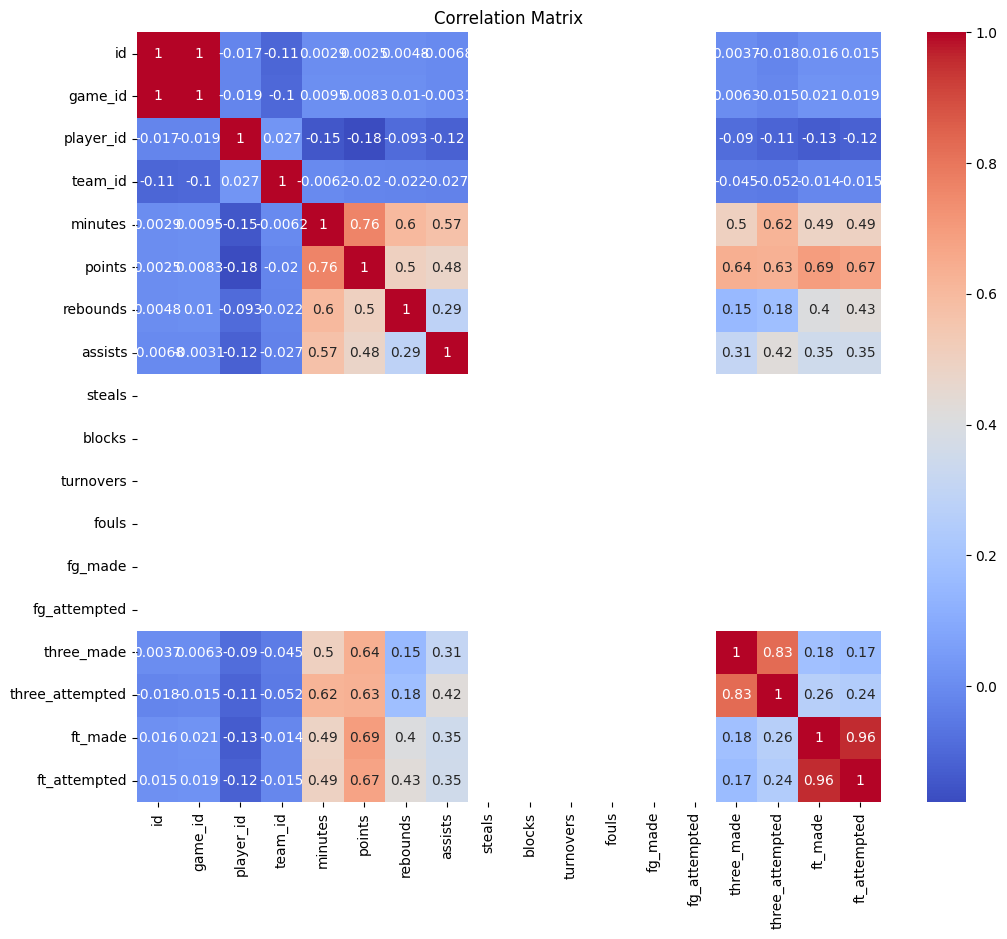

In [28]:
corr = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
